# Forecasting with Simple Exponential Smoothing

A short runthrough of Moving Average and the three forecasting methods, using Algeria's exports.

We cover:

1. **Moving average**, as a smoother
2. **Mean** and **Naive** forecasts, the two benchmarks
3. **Simple exponential smoothing (SES)**, which sits between the mean and the naive method
4. **Evaluation** with MASE and AICc

**Data.** Algeria, exports of goods and services (% of GDP), yearly, 1960 to 2025.
Source: World Bank Group, World Development Indicators. FPP uses this same series for its SES example.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

OBS   = "#2b2b2b"   # observed data
TRAIN = "#4878a8"   # training period
TEST  = "#d1671f"   # test period / actuals
SES   = "#c0392b"   # SES
MA    = "#2e8b57"   # moving average
MEAN  = "#8e7cc3"   # mean method
NAIVE = "#7f8c8d"   # naive method

## 1. Load and clean the data

The World Bank file is laid out for spreadsheets, not code, so it needs four small fixes:

1. The first four lines are notes about the file (source and last update date), not data.
2. Every line ends with a stray comma, which pandas reads as an extra, empty column.
3. We pick Algeria's row by its country code, `DZA`, and turn it into a series with one value per year.
4. The year labels are text. We convert them into a yearly time index so the models know the data is annual.

In [2]:
data = "2026_WS_ses_demo.csv"

raw = pd.read_csv(data, skiprows=4)
raw = raw.loc[:, ~raw.columns.str.startswith("Unnamed")] #remove last column which contains no values

print(f"{raw.shape[0]} rows (countries and regions), {raw.shape[1]} columns")
raw.head()

265 rows (countries and regions), 70 columns


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,68.966660,69.636936,68.408864,66.703081,53.802538,67.323549,80.742814,79.858893,85.968815,NaN
1,Africa Eastern and Southern,AFE,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.684742,23.795044,25.336708,23.948825,22.191237,25.728269,27.033079,26.160466,25.521582,25.566559
2,Afghanistan,AFG,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,10.420817,14.342153,18.380042,16.235278,15.702752,NaN
3,Africa Western and Central,AFW,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.297292,25.084825,35.848111,36.950082,31.759536,40.092305,36.013486,32.669372,30.879522,22.977750


In [3]:
year_cols = [c for c in raw.columns if c.isdigit()]

y = raw.loc[raw["Country Code"] == "DZA", year_cols].iloc[0].astype(float)
y.index = pd.PeriodIndex(y.index.astype(int), freq="Y")
y.name = "exports_pct_gdp"

print(f"{len(y)} years, {y.index[0]} to {y.index[-1]}")
print(f"missing years: {y.isna().sum()}")
y.tail()

66 years, 1960 to 2025
missing years: 0


2021    23.444367
2022    30.791556
2023    23.790060
2024    19.852380
2025    16.834775
Freq: Y-DEC, Name: exports_pct_gdp, dtype: float64

## 2. Data Visualisation

Exports have ranged from about 13% of GDP (1986) to 46% (1961). Algeria's exports are mostly oil and gas, so the share tends to rise and fall with energy prices: the 1986 low came with that year's oil price collapse, and the 2000s were a long high.

There is no steady climb or decline across the whole period, and yearly data has no seasonal pattern, hence the conditions are met to try SES.

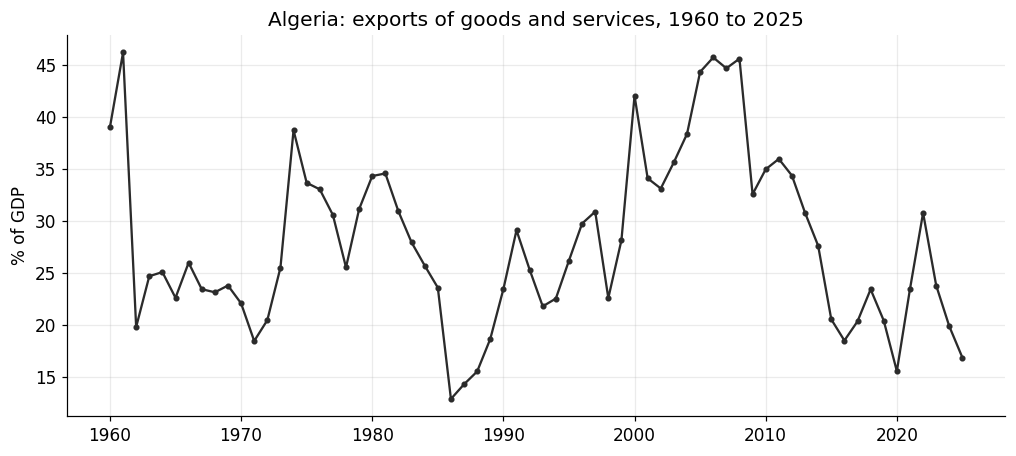

In [4]:
fig, ax = plt.subplots()
ax.plot(y.index.year, y.values, color=OBS, lw=1.5, marker="o", ms=3)
ax.set_title("Algeria: exports of goods and services, 1960 to 2025")
ax.set_ylabel("% of GDP")
plt.show()

## 3. Moving average

A centred moving averages of order 3 and 9, written 3-MA and 9-MA respectively.

This smooths out year to year noise so the broader movement is easier to see. Because it needs data before of after the year depending on its order, it is a tool best at describing the past rather than forecasting.

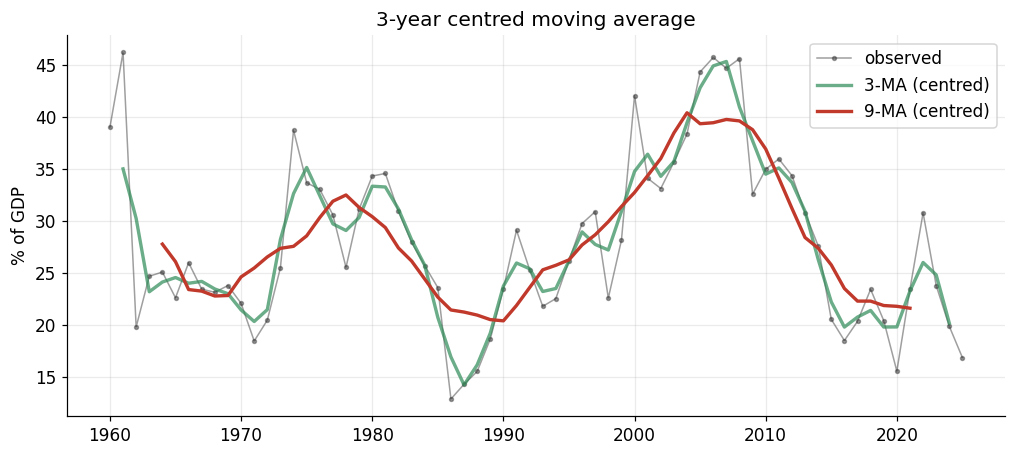

In [5]:
ma3 = y.rolling(window=3, center=True).mean()
ma9 = y.rolling(window=9, center=True).mean()

fig, ax = plt.subplots()
ax.plot(y.index.year, y.values, color=OBS, lw=1, alpha=0.45, marker="o", ms=2.5, label="observed")
ax.plot(ma3.index.year, ma3.values, color=MA, lw=2.2, alpha = 0.70, label="3-MA (centred)")
ax.plot(ma9.index.year, ma9.values, color=SES, lw=2.2, label="9-MA (centred)")
ax.set_title("3-year centred moving average")
ax.set_ylabel("% of GDP")
ax.legend()
plt.show()

## 4. Train / test split

We train on **1960 to 2017** and test on **2018 to 2025**.

We should acknowledge that eight test years is a small sample, and it includes the 2020 pandemic drop and the 2022 energy price spike.

In [6]:
train, test = y[:"2017"], y["2018":]
H = len(test)

print(f"train: {train.index[0]} to {train.index[-1]}, {len(train)} years")
print(f"test : {test.index[0]} to {test.index[-1]}, {H} years")

train: 1960 to 2017, 58 years
test : 2018 to 2025, 8 years


## 5. Three forecasting methods

A quick refresher. $\hat{y}_{T+h|T}$ is the forecast $h$ years ahead, made with data up to year $T$.

- **Mean**: $\hat{y}_{T+h|T} = \bar{y}$. Every past year counts equally.
- **Naive**: $\hat{y}_{T+h|T} = y_T$. Only the latest year counts.
- **SES**: $\hat{y}_{T+h|T} = \ell_T$ Recent years count more and older years fade, with $\alpha$ setting how fast.

All three give flat forecasts. Estimation picks the $\alpha$ that minimise the squared one step errors.

In [7]:
def fit_ses(series, alpha=None):
    model = SimpleExpSmoothing(series, initialization_method="estimated")
    return model.fit() if alpha is None else model.fit(smoothing_level=alpha)

fits = {
    "Mean":  fit_ses(train, alpha=0.0),
    "Naive": fit_ses(train, alpha=1.0),
    "SES":   fit_ses(train),
}
forecasts = {name: f.forecast(H) for name, f in fits.items()}
colours = {"Mean": MEAN, "Naive": NAIVE, "SES": SES}

print(f"training mean      : {train.mean():.3f}")
print(f"last training year : {train.iloc[-1]:.3f}")

pd.DataFrame({
    "alpha":         {n: f.params["smoothing_level"] for n, f in fits.items()},
    "forecast":      {n: fc.iloc[0] for n, fc in forecasts.items()},
}).round(3)

training mean      : 28.807
last training year : 20.334


,alpha,forecast
Mean,0.00,28.807
Naive,1.00,20.334
SES,0.82,20.113


## 6. Visualisation of one step ahead forecasts for each methods

Each coloured line shows the method's **fitted values**. For each year, roughly the forecast it would have made from the years before. Strictly, these are not true forecasts, because parameters such as the mean or $\alpha$ were estimated using all the training years.

- **Mean**: a flat line at the average.
- **Naive**: the series shifted one year to the right.
- **SES**: follows the series, slightly smoothed and lagged.

We estimate $\alpha = 0.82$.

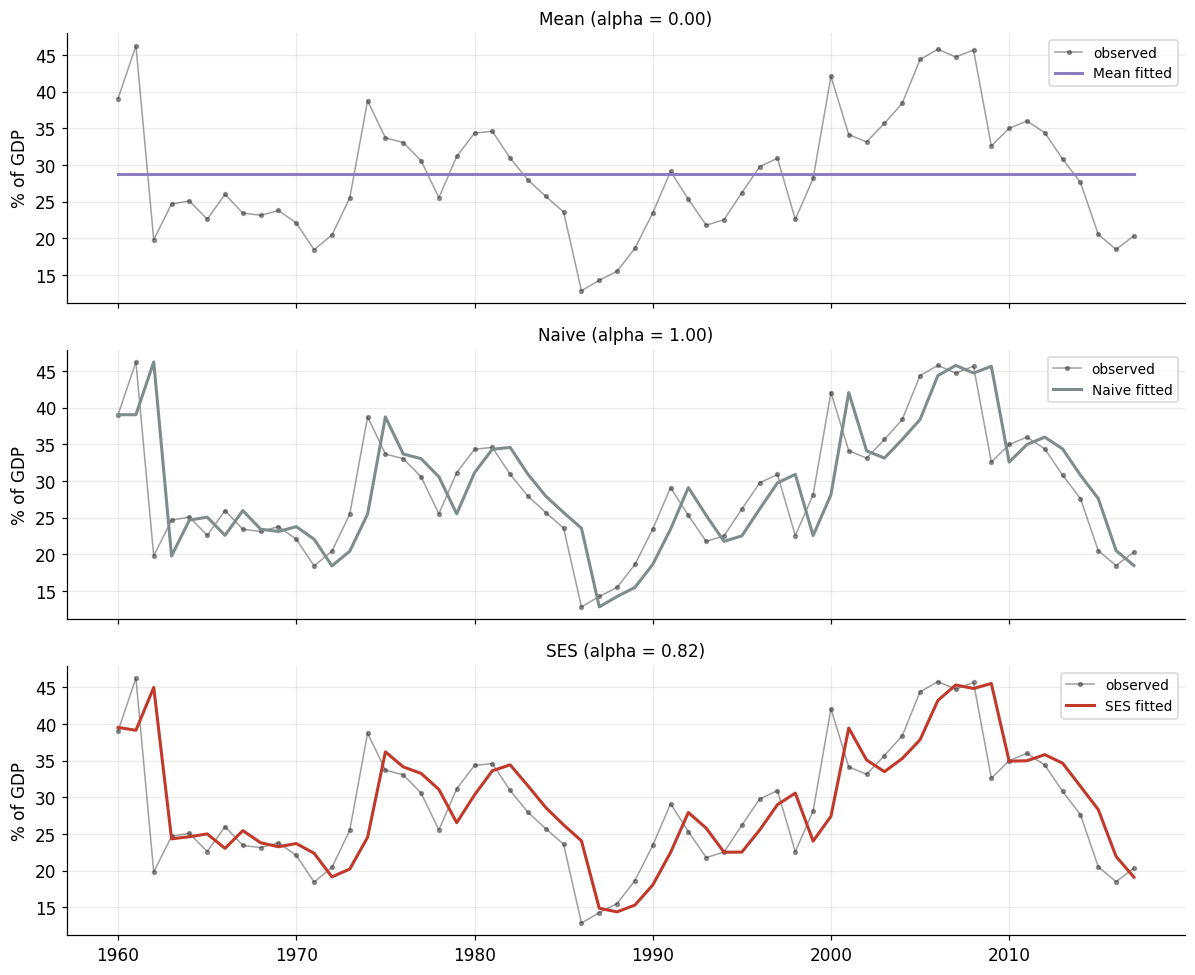

In [8]:
yrs = train.index.year

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, sharey=True)
for ax, (name, f) in zip(axes, fits.items()):
    ax.plot(yrs, train.values, color=OBS, lw=1, alpha=0.45, marker="o", ms=2.5, label="observed")
    ax.plot(yrs, np.asarray(f.fittedvalues), color=colours[name], lw=2, label=f"{name} fitted")
    ax.set_title(f"{name} (alpha = {f.params['smoothing_level']:.2f})", fontsize=11)
    ax.set_ylabel("% of GDP")
    ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## 7. Evaluation: MASE and AICc

The two measures answer different questions.

**MASE** asks how good the forecasts were for the test years. Each test error is divided by the average error the naive method made one step ahead on the training years:

$$q_j = \frac{e_j}{\frac{1}{T-1}\sum_{t=2}^{T}|y_t - y_{t-1}|}, \qquad \text{MASE} = \text{mean}(|q_j|)$$

To put it simply, MASE is a fraction where the denominator is mean absolute error of the model on training data and numerator is mean absolute error of the model forecast on test data.

**AICc** asks how well the model fits the training years, after a penalty for every quantity it estimated:

$$\text{AIC} = -2\log(L) + 2k, \qquad \text{AIC}_c = \text{AIC} + \frac{2k(k+1)}{T-k-1}$$

$L$ is the likelihood and $k$ counts everything estimated, including the residual variance. Mean and naive estimate only a starting level (plus the variance), so $k = 2$. SES also estimates $\alpha$, so $k = 3$. Lower is better, but only the differences between models mean anything, and only when the models are fitted to the same data, as they are here. 

In [9]:
def mase(actual, forecast, train):
    scale = np.mean(np.abs(np.diff(train.values)))
    return np.mean(np.abs(actual.values - forecast.values)) / scale

def aicc(resid, k):
    T = len(resid)
    # Gaussian log likelihood, with the variance estimated as the mean squared residual
    loglik = -T / 2 * (np.log(2 * np.pi * np.mean(resid ** 2)) + 1)
    aic = -2 * loglik + 2 * k
    return aic + 2 * k * (k + 1) / (T - k - 1)

k_params = {"Mean": 2, "Naive": 2, "SES": 3}

results = pd.DataFrame({
    "alpha": {n: f.params["smoothing_level"] for n, f in fits.items()},
    "k":     k_params,
    "AICc":  {n: aicc(np.asarray(f.resid), k_params[n]) for n, f in fits.items()},
    "MASE":  {n: mase(test, forecasts[n], train) for n in fits},
})
results["AICc minus lowest"] = results["AICc"] - results["AICc"].min()

results.round(3)

,alpha,k,AICc,MASE,AICc minus lowest
Mean,0.00,2,412.840,1.808,36.860
Naive,1.00,2,375.980,0.868,0.000
SES,0.82,3,376.763,0.881,0.783


## 8. All three forecasts together

Naive (thick grey band) and SES (red dashes) sit almost on top of each other, which is itself worth pointing out.

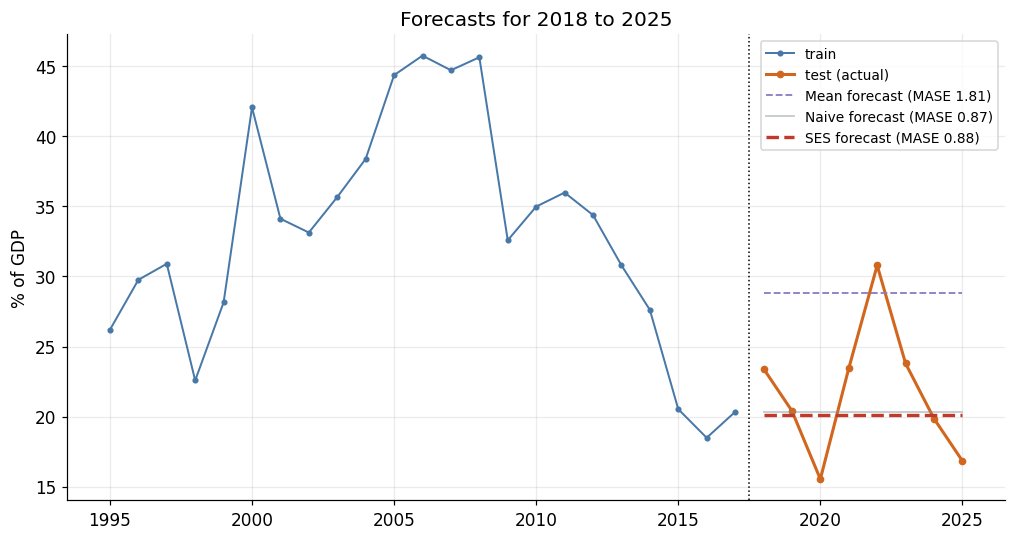

In [11]:
recent = train["1995":]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(recent.index.year, recent.values, color=TRAIN, lw=1.3, marker="o", ms=3, label="train")
ax.plot(test.index.year, test.values, color=TEST, lw=2, marker="o", ms=4, label="test (actual)")
styles = {"Mean": dict(ls="--", lw=1.2), "Naive": dict(ls="-", lw=1.2, alpha=0.45), "SES": dict(ls="--", lw=2.2)}
for name, fc in forecasts.items():
    ax.plot(fc.index.year, fc.values, color=colours[name], **styles[name],
            label=f"{name} forecast (MASE {results.loc[name, 'MASE']:.2f})")
ax.axvline(2017.5, color="k", ls=":", lw=1)
ax.set_title("Forecasts for 2018 to 2025")
ax.set_ylabel("% of GDP")
ax.legend(fontsize=9)
plt.show()

## 9. Which seems better?

**Naive and SES are close to a tie, and both are clearly better than the mean.**

- **The mean is worst on both measures**: MASE 1.81, and an AICc roughly 36 to 37 points above the other two. Averaging all 58 years pulls in the 2000s, when exports averaged about 40% of GDP, well above where Algeria has been since.
- **Naive edges SES on both, but only just**: MASE 0.87 against 0.88, and an AICc lower by less than one point. With $\alpha = 0.82$, SES already puts most of its weight on the latest year, so its forecast barely differs from naive's. Estimating $\alpha$ improved the fit on the training years slightly, but not by enough to cover the AICc penalty for the extra parameter.

As explained earlier, Naive methods performed slightly better on this dataset against Exponential Smoothing, showing that it is a legitimate forecasting strategy. So in this case, having more weighted information about the past did little to improve forecast performance.